# Loading Dataset

In [1]:
import kagglehub
path = kagglehub.dataset_download("leoscode/wound-segmentation-images")

100%|██████████| 665M/665M [00:08<00:00, 78.5MB/s]

Extracting files...


In [ ]:
import os

print("Dataset Path:", path)
print(os.listdir(path))

Dataset Path: /root/.cache/kagglehub/datasets/leoscode/wound-segmentation-images/versions/1
['data_wound_seg']


In [ ]:
for root, dirs, files in os.walk(path):
    print("Root:", root)
    print("Dirs:", dirs)
    print("Files:", len(files))
    break

Root: /root/.cache/kagglehub/datasets/leoscode/wound-segmentation-images/versions/1
Dirs: ['data_wound_seg']
Files: 0


In [ ]:
base_path = path + "/data_wound_seg"

train_img_path = base_path + "/train_images"
train_mask_path = base_path + "/train_masks"

test_img_path = base_path + "/test_images"
test_mask_path = base_path + "/test_masks"

In [ ]:
import os
import cv2
import numpy as np
import shutil

dataset_path = "/content/dataset"
train_dir = dataset_path + "/train"
val_dir = dataset_path + "/val"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

from sklearn.model_selection import train_test_split

images = os.listdir(train_img_path)

train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

def process_and_copy(img_list, target_dir):
    for img_name in img_list:
        img_path = os.path.join(train_img_path, img_name)
        mask_path = os.path.join(train_mask_path, img_name)

        mask = cv2.imread(mask_path, 0)  # grayscale

        # Check if wound exists
        if np.sum(mask) > 0:
            label = "wound"
        else:
            label = "normal"

        os.makedirs(os.path.join(target_dir, label), exist_ok=True)

        shutil.copy(img_path, os.path.join(target_dir, label, img_name))

# Create dataset
process_and_copy(train_imgs, train_dir)
process_and_copy(val_imgs, val_dir)

In [ ]:
for cls in os.listdir(train_dir):
    print(cls, ":", len(os.listdir(os.path.join(train_dir, cls))))

wound : 1757
normal : 9


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
val_data = datasets.ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

print("Classes:", train_data.classes)

Classes: ['normal', 'wound']


In [ ]:
import random
import shutil

normal_path = train_dir + "/normal"
normal_images = os.listdir(normal_path)

target_count = 1000  # match closer to wound count

for i in range(target_count - len(normal_images)):
    img = random.choice(normal_images)

    src = os.path.join(normal_path, img)
    dst = os.path.join(normal_path, f"aug_{i}_{img}")

    shutil.copy(src, dst)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
import torch

# Define device before use
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_counts = [len(os.listdir(train_dir + "/normal")),
                len(os.listdir(train_dir + "/wound"))]

weights = torch.tensor([
    1.0/class_counts[0],
    1.0/class_counts[1]
])

weights = weights / weights.sum()

criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))

In [ ]:
from torch.utils.data import WeightedRandomSampler

targets = train_data.targets
# Convert targets to a torch.Tensor for element-wise operations
targets_tensor = torch.tensor(targets)

class_sample_count = torch.tensor([
    (targets_tensor == 0).sum(),
    (targets_tensor == 1).sum()
], dtype=torch.float)

weights = 1. / class_sample_count
sample_weights = weights[targets_tensor] # Use targets_tensor here as well

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_data, batch_size=32, sampler=sampler)

In [ ]:
selected_wounds = random.sample(os.listdir(train_dir + "/wound"), 1000)

In [ ]:
for cls in os.listdir(train_dir):
    print(cls, ":", len(os.listdir(os.path.join(train_dir, cls))))

wound : 1757
normal : 1000


In [ ]:
import os
import random

wound_path = train_dir + "/wound"

all_wounds = os.listdir(wound_path)
selected_wounds = random.sample(all_wounds, 1000)

# Remove extra images
for img in all_wounds:
    if img not in selected_wounds:
        os.remove(os.path.join(wound_path, img))

In [ ]:
for cls in os.listdir(train_dir):
    print(cls, ":", len(os.listdir(os.path.join(train_dir, cls))))

wound : 1000
normal : 1000


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
val_data = datasets.ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

print(train_data.classes)

['normal', 'wound']


# Training

### ResNet

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

In [ ]:
for epoch in range(10):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 4.8671
Epoch 2, Loss: 0.9889
Epoch 3, Loss: 0.1631
Epoch 4, Loss: 0.1713
Epoch 5, Loss: 0.0462
Epoch 6, Loss: 0.1126
Epoch 7, Loss: 0.0285
Epoch 8, Loss: 0.0079
Epoch 9, Loss: 0.0098
Epoch 10, Loss: 0.0071


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total)

Validation Accuracy: 99.5475113122172


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[  0   2]
 [  0 440]]


# Week 3

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((64,64)),   # smaller for MLP
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
val_data = datasets.ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

In [ ]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64*64*3, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = MLP().to(device)

In [ ]:
import torch.optim as optim

def train_model(lr):
    model = MLP().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    losses = []

    for epoch in range(5):
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss)
        print(f"LR {lr} Epoch {epoch+1}: Loss {total_loss}")

    return losses

In [ ]:
loss1 = train_model(0.1)
loss2 = train_model(0.01)
loss3 = train_model(0.001)

LR 0.1 Epoch 1: Loss 38.0434812605381
LR 0.1 Epoch 2: Loss 34.98172937333584
LR 0.1 Epoch 3: Loss 23.66207654774189
LR 0.1 Epoch 4: Loss 26.077760338783264
LR 0.1 Epoch 5: Loss 22.988349571824074
LR 0.01 Epoch 1: Loss 23.59232449531555
LR 0.01 Epoch 2: Loss 14.952856242656708
LR 0.01 Epoch 3: Loss 9.772269010543823
LR 0.01 Epoch 4: Loss 6.327819064259529
LR 0.01 Epoch 5: Loss 4.81078945286572
LR 0.001 Epoch 1: Loss 33.727829307317734
LR 0.001 Epoch 2: Loss 25.95300680398941
LR 0.001 Epoch 3: Loss 22.788026124238968
LR 0.001 Epoch 4: Loss 20.8941607773304
LR 0.001 Epoch 5: Loss 19.52770821750164


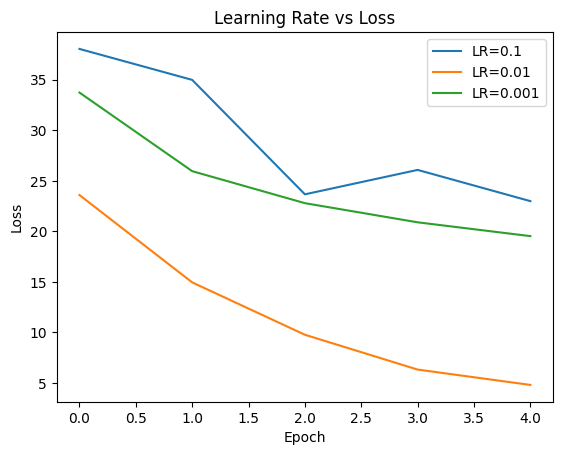

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss1, label="LR=0.1")
plt.plot(loss2, label="LR=0.01")
plt.plot(loss3, label="LR=0.001")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Learning Rate vs Loss")
plt.show()

# Week 4

### Optimizations

In [ ]:
import torch.optim as optim

def train_with_optimizer(optimizer_name):
    model = MLP().to(device)

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == "Momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    elif optimizer_name == "RMSProp":
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)

    criterion = nn.CrossEntropyLoss()

    losses = []

    for epoch in range(5):
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss)
        print(f"{optimizer_name} Epoch {epoch+1}: Loss {total_loss}")

    return losses

In [ ]:
loss_sgd = train_with_optimizer("SGD")
loss_momentum = train_with_optimizer("Momentum")
loss_adam = train_with_optimizer("Adam")
loss_rms = train_with_optimizer("RMSProp")

SGD Epoch 1: Loss 23.1142800450325
SGD Epoch 2: Loss 13.883866898715496
SGD Epoch 3: Loss 10.719268821179867
SGD Epoch 4: Loss 7.771656569093466
SGD Epoch 5: Loss 4.865993529558182
Momentum Epoch 1: Loss 17.03174940869212
Momentum Epoch 2: Loss 2.681855358183384
Momentum Epoch 3: Loss 0.775465777842328
Momentum Epoch 4: Loss 0.7744438204681501
Momentum Epoch 5: Loss 0.2864837900415296
Adam Epoch 1: Loss 40.74306210875511
Adam Epoch 2: Loss 4.308141203597188
Adam Epoch 3: Loss 2.0267246584407985
Adam Epoch 4: Loss 1.08009988325648
Adam Epoch 5: Loss 0.5838215595576912
RMSProp Epoch 1: Loss 223.21878091036342
RMSProp Epoch 2: Loss 21.406685520894825
RMSProp Epoch 3: Loss 5.905634369701147
RMSProp Epoch 4: Loss 11.443514516577125
RMSProp Epoch 5: Loss 6.389459330588579


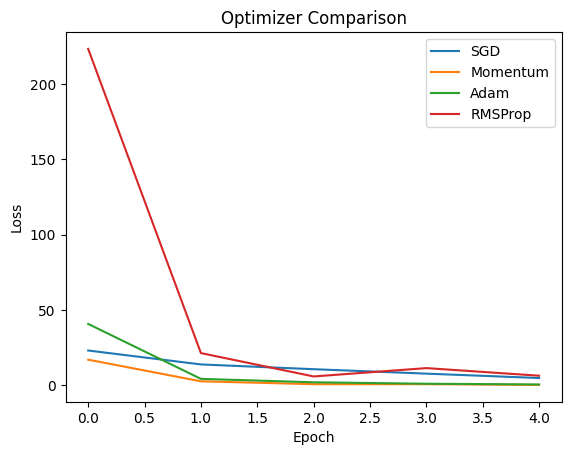

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_sgd, label="SGD")
plt.plot(loss_momentum, label="Momentum")
plt.plot(loss_adam, label="Adam")
plt.plot(loss_rms, label="RMSProp")

plt.legend()
plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Week 5

In [ ]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64*64*3, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


class MLP_Reg(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64*64*3, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
import torch

def train_and_evaluate(model, optimizer, name):
    criterion = nn.CrossEntropyLoss()

    for epoch in range(5):
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # VALIDATION
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        acc = 100 * correct / total

        print(f"{name} Epoch {epoch+1} | Loss: {train_loss:.2f} | Val Acc: {acc:.2f}%")

In [ ]:
import torch.optim as optim

model1 = MLP().to(device)
optimizer1 = optim.SGD(model1.parameters(), lr=0.01)

train_and_evaluate(model1, optimizer1, "No Reg")

No Reg Epoch 1 | Loss: 24.13 | Val Acc: 77.83%
No Reg Epoch 2 | Loss: 15.89 | Val Acc: 83.94%
No Reg Epoch 3 | Loss: 10.47 | Val Acc: 98.42%
No Reg Epoch 4 | Loss: 7.38 | Val Acc: 95.02%
No Reg Epoch 5 | Loss: 5.27 | Val Acc: 99.10%


In [ ]:
model2 = MLP_Reg().to(device)

optimizer2 = optim.SGD(
    model2.parameters(),
    lr=0.01,
    weight_decay=0.001  # L2
)

train_and_evaluate(model2, optimizer2, "With Reg")

With Reg Epoch 1 | Loss: 25.36 | Val Acc: 91.40%
With Reg Epoch 2 | Loss: 16.18 | Val Acc: 94.80%
With Reg Epoch 3 | Loss: 11.51 | Val Acc: 96.38%
With Reg Epoch 4 | Loss: 8.27 | Val Acc: 98.87%
With Reg Epoch 5 | Loss: 6.54 | Val Acc: 92.08%


# Week 6

In [ ]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [ ]:
model = CNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

Epoch 1, Loss: 17.30
Epoch 2, Loss: 4.11
Epoch 3, Loss: 0.48
Epoch 4, Loss: 0.19
Epoch 5, Loss: 0.03


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("CNN Accuracy:", 100 * correct / total)

CNN Accuracy: 99.5475113122172


# Week 7

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

Epoch 1, Loss: 2.00
Epoch 2, Loss: 0.03
Epoch 3, Loss: 0.06
Epoch 4, Loss: 0.01
Epoch 5, Loss: 0.01


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("ResNet Accuracy:", 100 * correct / total)

ResNet Accuracy: 99.5475113122172


In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.vgg16(pretrained=True)

# Replace classifier
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 71.5MB/s]


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

Epoch 1, Loss: 6.45
Epoch 2, Loss: 0.00
Epoch 3, Loss: 0.00
Epoch 4, Loss: 0.00
Epoch 5, Loss: 0.00


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("VGG Accuracy:", 100 * correct / total)

VGG Accuracy: 99.5475113122172


# Week 8

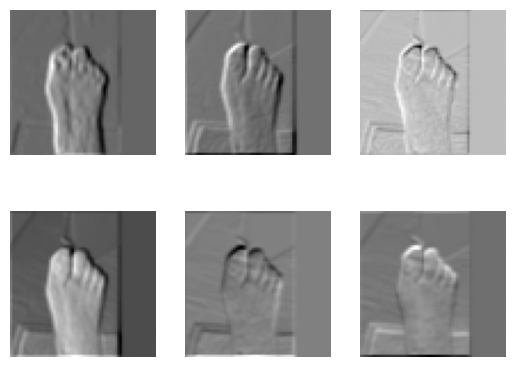

In [ ]:
import matplotlib.pyplot as plt

# take one batch
images, _ = next(iter(train_loader))
image = images[0].unsqueeze(0).to(device)

model.eval()

# get first conv layer output
with torch.no_grad():
    feature_maps = model.features[0](image)

feature_maps = feature_maps.cpu().squeeze()

# plot first 6 feature maps
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[i], cmap='gray')
    plt.axis('off')

plt.show()

# Week 11

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64*3, 256),
            nn.ReLU(),
            nn.Linear(256, 64)
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 64*64*3),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, 3, 64, 64)

In [ ]:
model = AutoEncoder().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(5):
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 2.9496
Epoch 2, Loss: 1.2130
Epoch 3, Loss: 0.9231
Epoch 4, Loss: 0.8314
Epoch 5, Loss: 0.7826


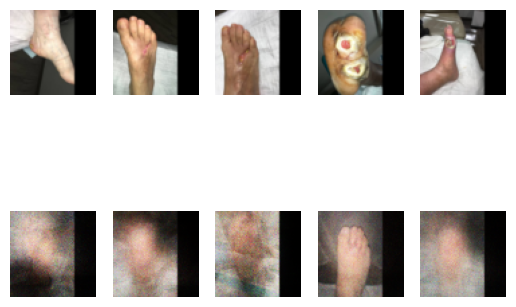

In [ ]:
import matplotlib.pyplot as plt

model.eval()
images, _ = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

# show original vs reconstructed
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].cpu().permute(1,2,0))
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(outputs[i].cpu().permute(1,2,0))
    plt.axis('off')

plt.show()